## Imports

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import json

## Load data

In [9]:
sim_dt = "2025-10-03-225103Z"
sim_data_filename = f"../simulation_data/SEIR_Neighbors_Simulation_Data-{sim_dt}.csv"
sim_params_filename = f"../simulation_data/SEIR_Neighbors_Simulation_Params-{sim_dt}.json"

In [10]:
df = pd.read_csv(sim_data_filename)
groups = [g for g in df.columns if g != 'time']

df = (
    df
    .melt(id_vars=['time'], value_vars=groups, var_name="grp", value_name="count")
    .assign(grp = lambda _df: pd.Categorical(_df.grp, categories=groups, ordered=True))
    .sort_values(by=["time", "grp"], ascending=[True, False])
    .reset_index(drop=True)
)
df.head(5)

,time,grp,count
0,0,recovered,0
1,0,infected,50
2,0,exposed,0
3,0,susceptible,950
4,1,recovered,0


In [11]:
with open(sim_params_filename, "r") as file:
        sim_params = json.load(file)
sim_params

{'random_seed': 42,
 'n_agents': 1000,
 'sim_duration': 365,
 'output_path': 'simulation_data',
 'initially_infected': 50,
 'beta': 0.01,
 'gamma': 0.01,
 'sigma': 0.05,
 'e1': 1,
 'e2': 3,
 't1': 7,
 't2': 14,
 'simulation_start': '2025-10-03-225059Z',
 'simulation_end': '2025-10-03-225103Z',
 'simulation_duration_seconds': 3.448291,
 'agent_class': 'SEIRNeighborsFSMAgent'}

## Simulation Params

In [12]:
N_AGENTS = sim_params['n_agents']
BETA = sim_params['beta']
GAMMA = sim_params['gamma']
SIM_DURATION = sim_params['sim_duration']

## Visualization

### Style

In [13]:
color_map = {"susceptible": "#8da0cb", "infected": "#fc8d62", "recovered": "#66c2a5"}
title_text = f"SEIR Neighbor Agent Model<br>β={BETA}, γ={GAMMA}, Population Size={N_AGENTS}"

legend_params = dict(
    orientation="h",
    yanchor="bottom",
    y=-.3,
    xanchor="center",
    x=0.5,
    title_text="")

title_params=dict(text=title_text, font_size=20)

graph_params = dict(
    title=title_params,
    legend=legend_params,
    width=1000,
    height=500,
    template="presentation")

### Area Plot

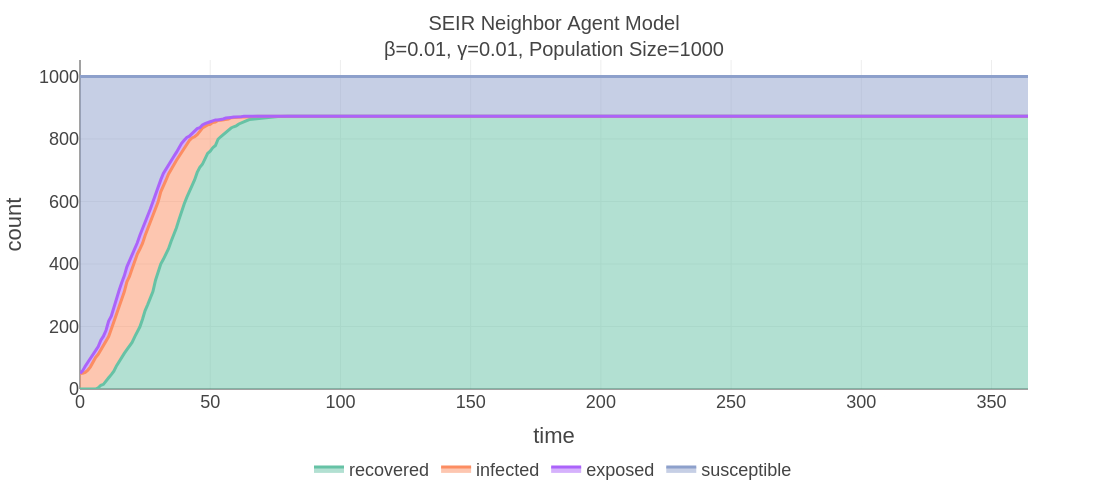

In [14]:
fig = px.area(df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params)
fig.show()

### Line Plot

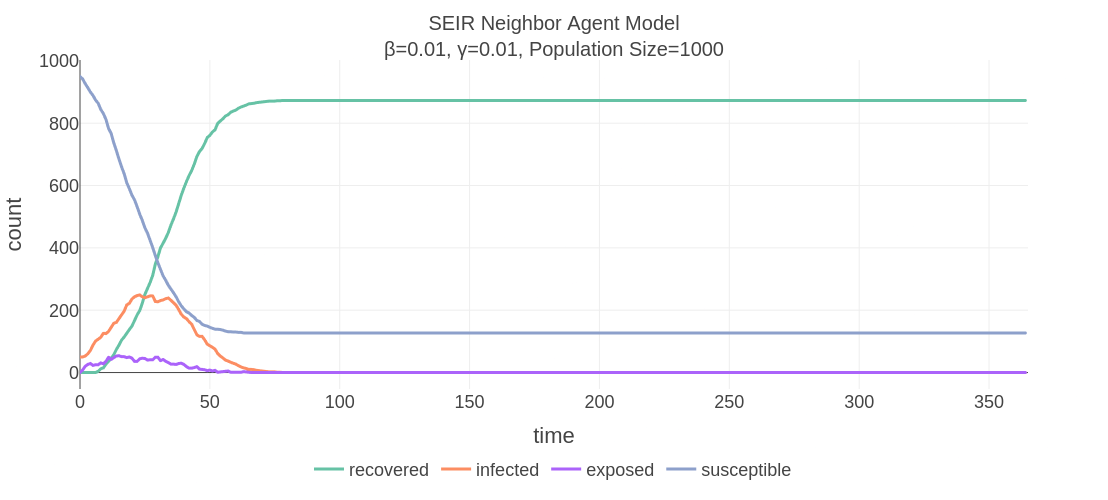

In [15]:
fig = px.line(df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365])
fig.show()

### Line plot animated

In [16]:
df2 = (
    pd.read_csv(sim_data_filename)
    .sort_values(by=["time"])
    .reset_index(drop=True)
)

In [ ]:
def create_animation_df(df, start=10, frame_cnt = SIM_DURATION, speed_up=1):
    df2 = pd.DataFrame()
    frame_cnt = int(frame_cnt / speed_up)
    for i in np.arange(start, frame_cnt):
        dfa = df.head(i*speed_up).copy()
        dfa['ix']=i
        df2 = pd.concat([df2, dfa])
    return df2

In [ ]:
animation_df = create_animation_df(df2, start=0, frame_cnt = SIM_DURATION, speed_up=8)

In [ ]:
fig = px.line(animation_df, 
              x="time", 
              y=groups, 
              animation_frame="ix", 
              color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365], yaxis_range=[0, 100])
fig.layout.updatemenus[0].buttons[0]['args'][1]['frame']['redraw'] = True
fig.show()